# Stock price analysis

In [1]:
# Importing packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import glob # to import all the files in the folder

In [2]:
# Importing all the files in the folder
glob.glob('/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/*csv')

['/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/XRX_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/GS_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/SPGI_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/MTB_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/V_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/CTAS_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/ESRX_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/APH_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/BBT_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/RHI_data.csv',
 '/Users/claudinha/Portfolio/Stock_Analysis/S&P_re

In [3]:
# Creating a list for only the interested companies (Apple, Amazon, Google, Microsoft)
company_list = [
    '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/AAPL_data.csv',
    '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/AMZN_data.csv',
    '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/GOOG_data.csv',
    '/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/MSFT_data.csv',
]

In [4]:
# Reading all the files in the list
all_data = pd.DataFrame()

for file in company_list:
    df = pd.read_csv(file)
    all_data = pd.concat([all_data, df], ignore_index=True)

In [5]:
# Checking the first 5 rows of the dataframe
all_data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [6]:
# Checking the unique names in the dataframe
all_data['Name'].unique()

array(['AAPL', 'AMZN', 'GOOG', 'MSFT'], dtype=object)

In [7]:
all_data.shape

(4752, 7)

# What was the change in price of the stock over time?

In [8]:
# Looking for null values
all_data.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [9]:
# Checking the data type of the dataframe
all_data.dtypes

date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object

In [10]:
# Date has to be converted to datetime
all_data['date'] = pd.to_datetime(all_data['date'])

In [11]:
# Creating a variable called 'Text_list' wit the names of the companies
Text_list = all_data['Name'].unique()

In [12]:
Text_list

array(['AAPL', 'AMZN', 'GOOG', 'MSFT'], dtype=object)

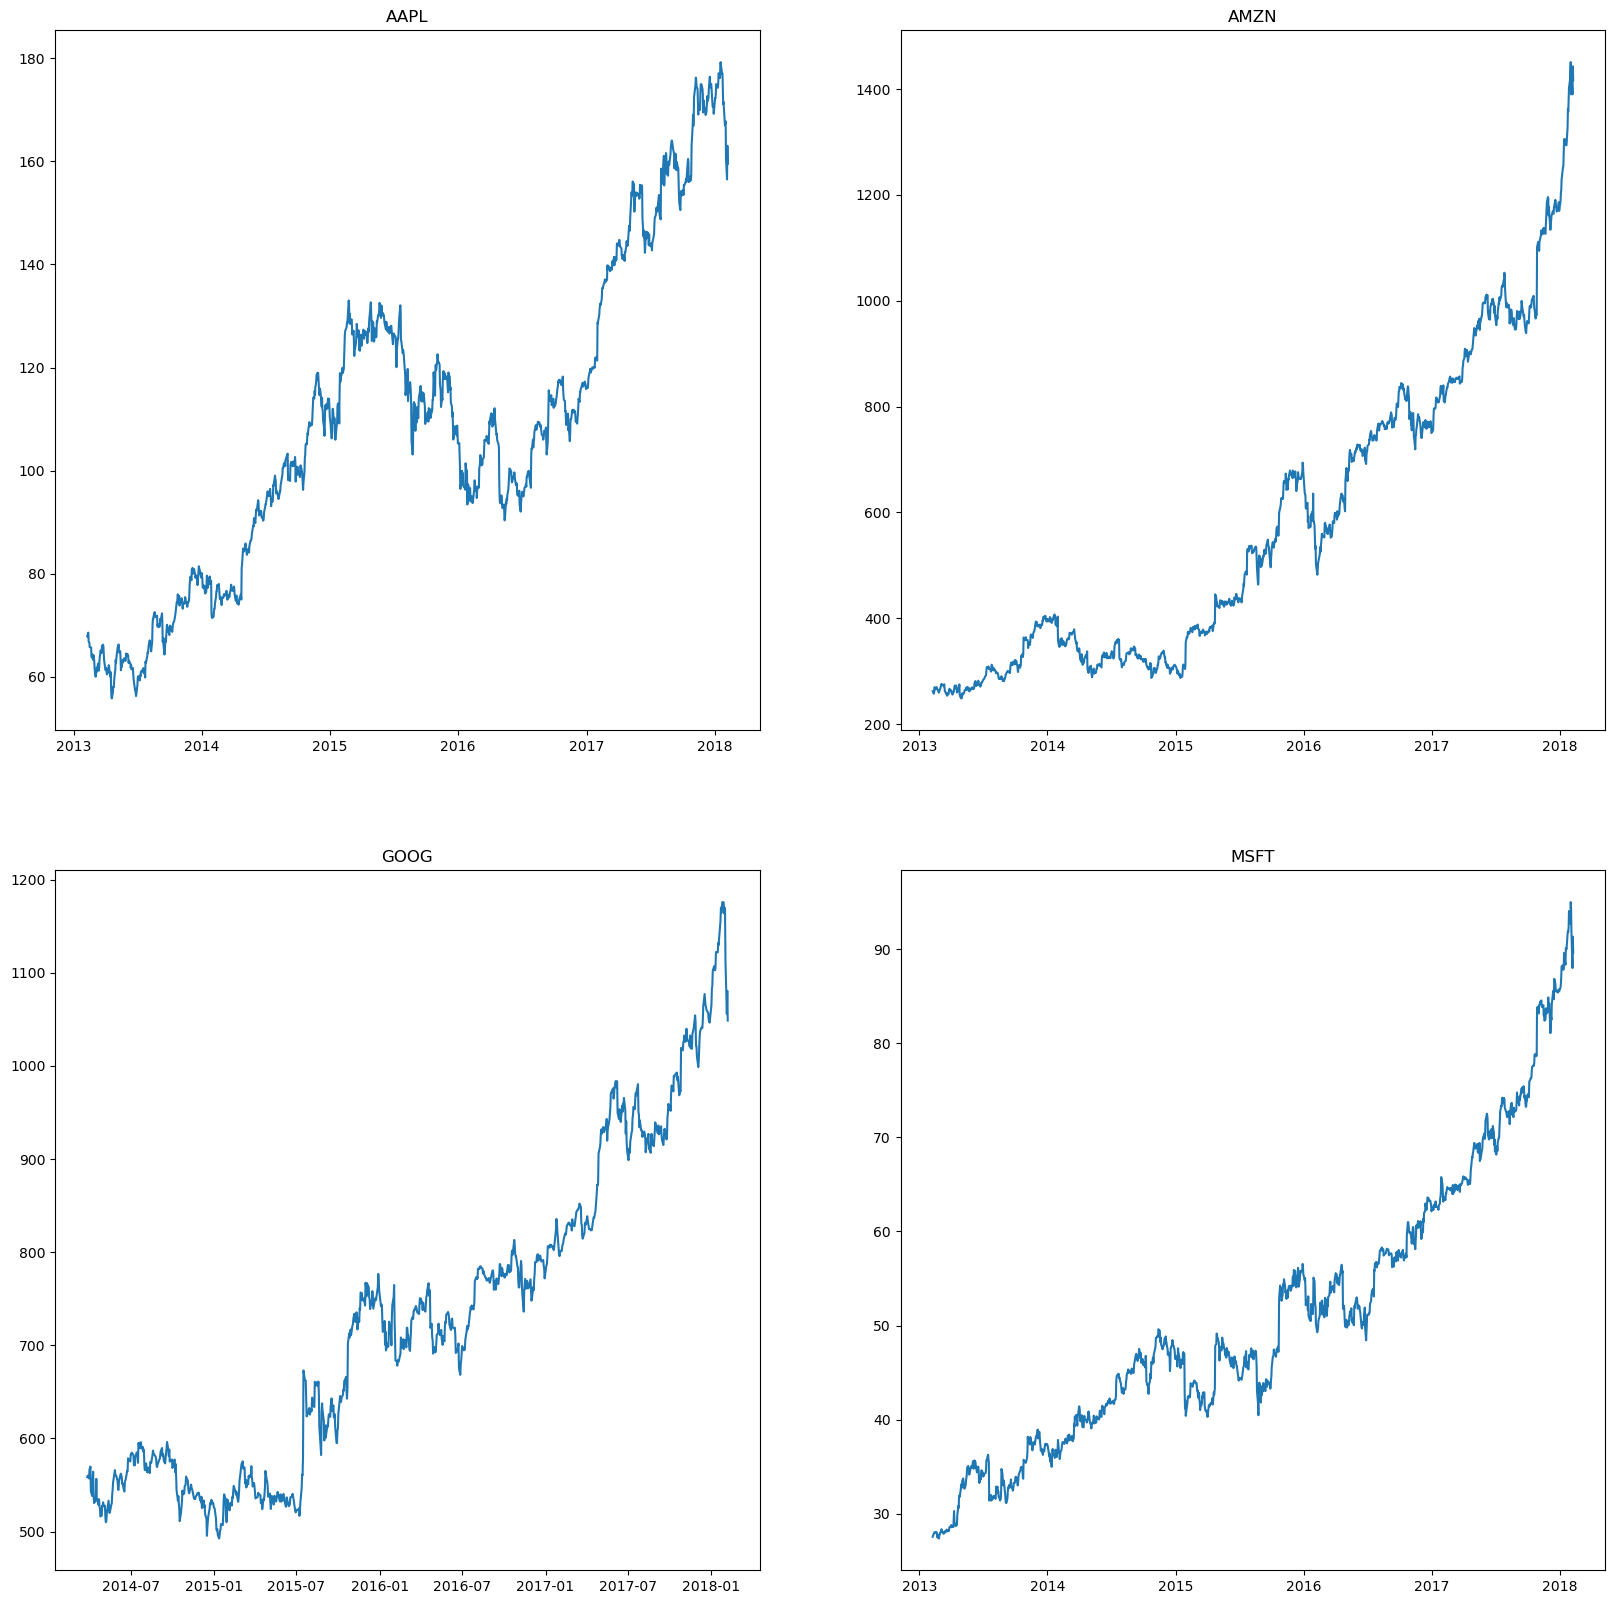

In [13]:
# Creating a figure for the change in price of the stock over time
plt.figure(figsize=(20, 20))

for index, company in enumerate(Text_list,1):
    plt.subplot(2,2,index)
    filter = all_data['Name'] == company #Plots only that company's series in each subplot.
    df = all_data[filter]
    plt.plot(df['date'],df['close'])
    plt.title(company)

* The figure shows the trends for each company in terms of price stock versus time. <br>
* AMAZON and Microsof has almost the same trend. <br>
* Apple achieve a peak in about 2015

# Moving average for the stocks

In [14]:
# Using rolling to get the average mean for a window of 10
all_data['close'].rolling(10).mean()


0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
         ...  
4747    92.765
4748    92.943
4749    92.582
4750    92.525
4751    92.304
Name: close, Length: 4752, dtype: float64

In [15]:
# Making a copy of the data
new_data = all_data.copy()

In [16]:
# Creating new columns witht the moving average for different windows
ma_day = [10, 20, 50] #moving average interval of days

for ma in ma_day:
    new_data['close_'+str(ma)] = new_data['close'].rolling(ma).mean()



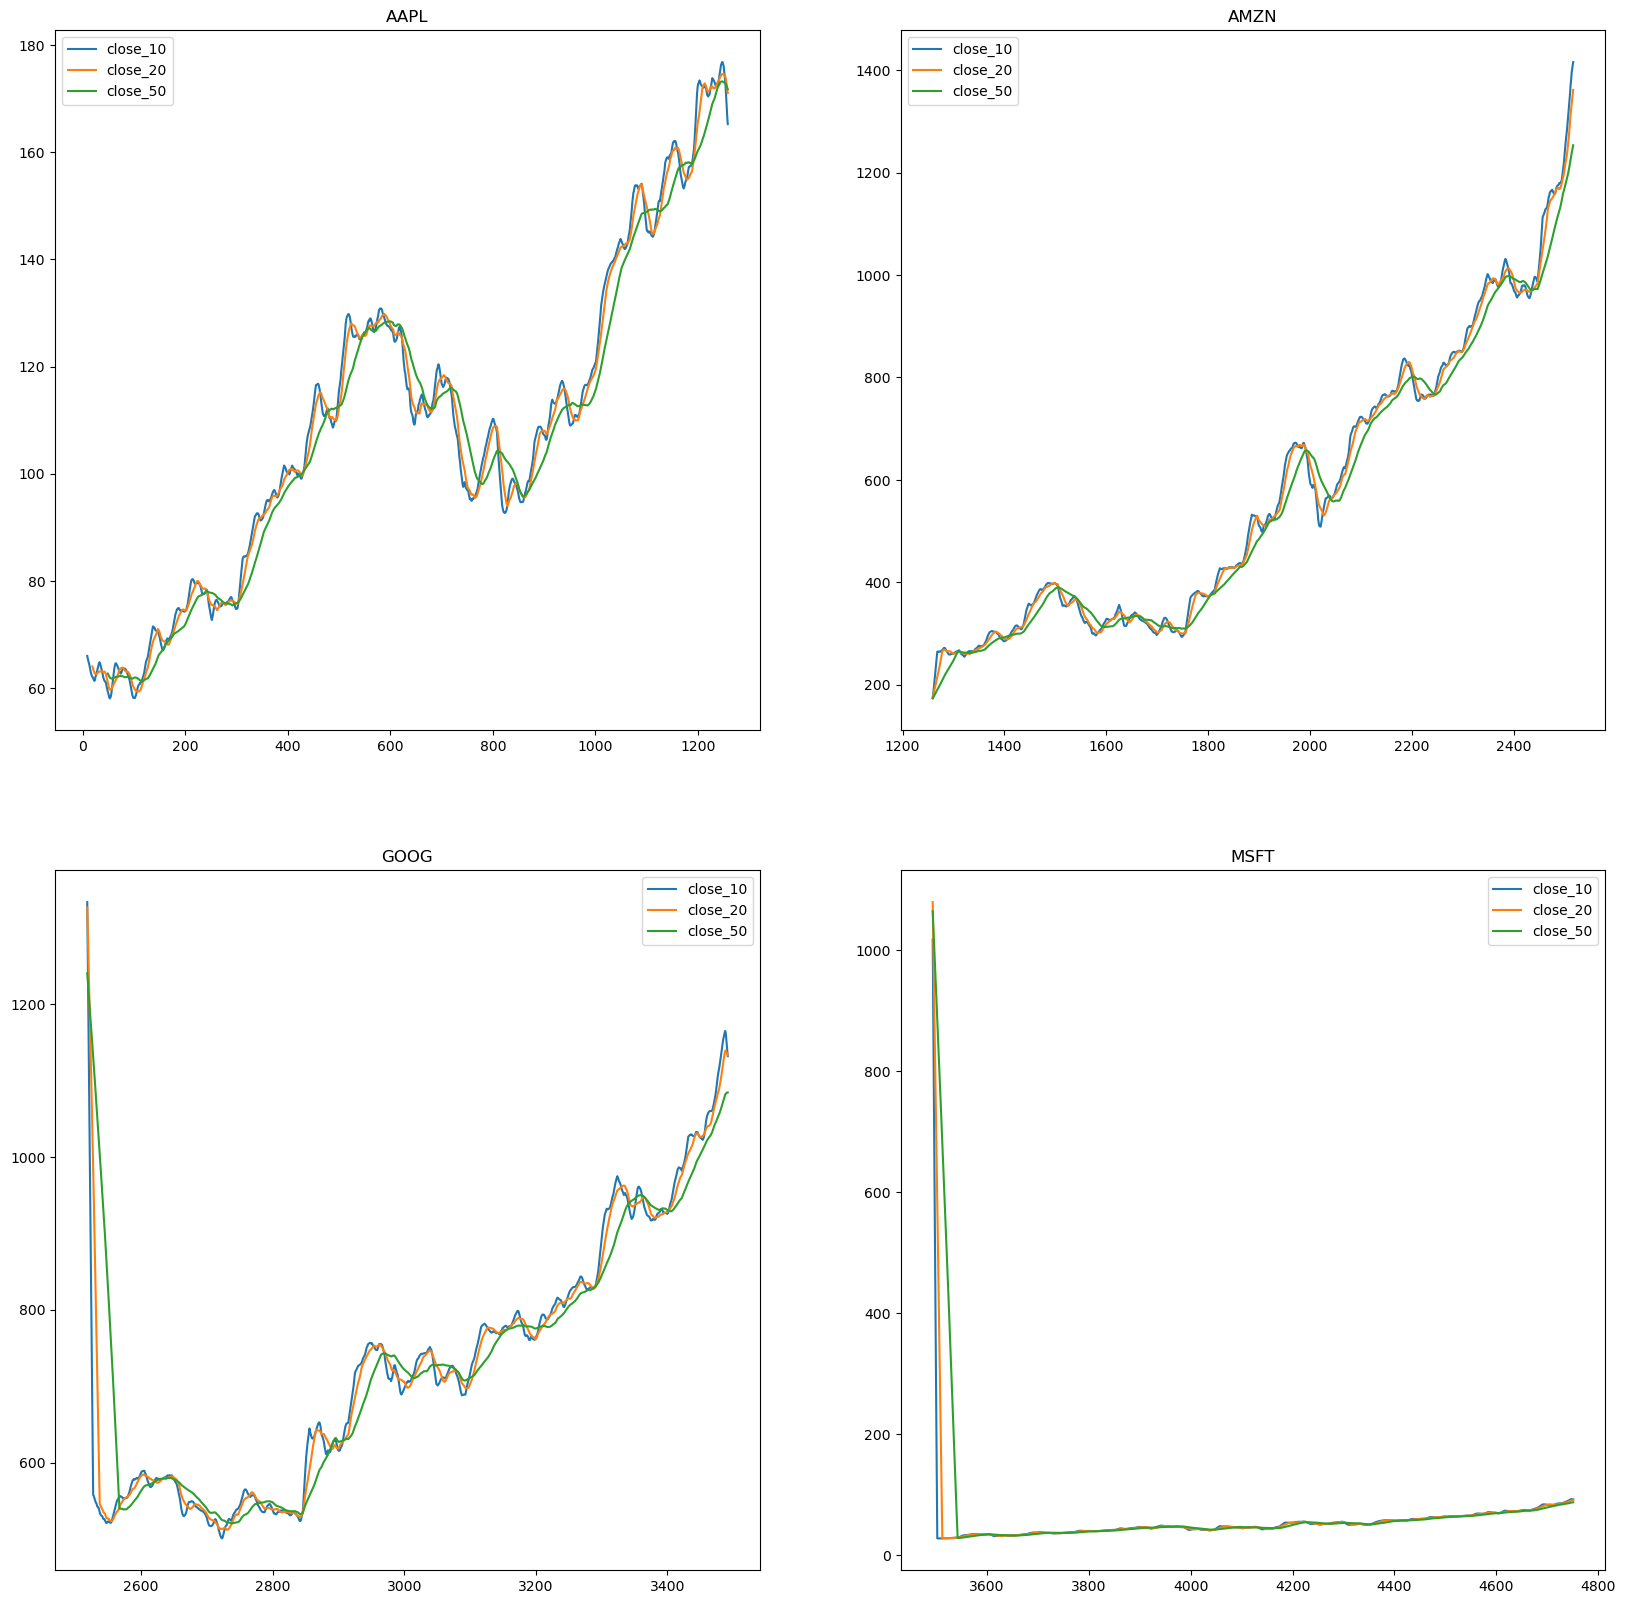

In [17]:
# Creatig the plot
plt.figure(figsize=(20, 20))

for index, company in enumerate(Text_list,1):
    plt.subplot(2,2,index)
    filter = new_data['Name'] == company #Plots only that company's series in each subplot.
    df = new_data[filter]
    df[['close_10','close_20','close_50']].plot(ax=plt.gca())
    plt.title(company)


# Analizing closing price change in Apple stock

In [18]:
# Getting the csv for aplle stocks
apple = pd.read_csv('/Users/claudinha/Portfolio/Stock_Analysis/S&P_resources/individual_stocks_5yr/AAPL_data.csv')

In [19]:
apple.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [20]:
# Creating the Daily return column for the percentual change beteween the current and the prior element
apple['Daily return (in %)'] = apple['close'].pct_change()*100

In [21]:
apple.head()

,date,open,high,low,close,volume,Name,Daily return (in %)
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,1.042235
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,-2.506658
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,-0.190297
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,-0.089934


In [22]:
# Importing plotly
import plotly.express as px

In [23]:
# Vizualizing the results
px.line(apple, x = 'date', y = 'Daily return (in %)')

# Performing resampling analysis of close price

In [24]:
apple.dtypes

date                    object
open                   float64
high                   float64
low                    float64
close                  float64
volume                   int64
Name                    object
Daily return (in %)    float64
dtype: object

In [25]:
# Getting date column into the right format
apple['date'] = pd.to_datetime(apple['date'])

In [26]:
# Setting the index to be the date
apple.set_index('date', inplace = True)

In [27]:
apple.head()

,open,high,low,close,volume,Name,Daily return (in %)
date,,,,,,,
2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN
2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,1.042235
2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,-2.506658
2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,-0.190297
2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,-0.089934


In [28]:
# Resampling the data on a monthly basis 
apple['close'].resample('M').mean() 

/var/folders/q3/rsyd34v93rd8xdld41qxtddm0000gn/T/ipykernel_1889/2140365517.py:2: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



date
2013-02-28     65.306264
2013-03-31     63.120110
2013-04-30     59.966432
2013-05-31     63.778927
2013-06-30     60.791120
                 ...    
2017-10-31    157.817273
2017-11-30    172.406190
2017-12-31    171.891500
2018-01-31    174.005238
2018-02-28    161.468000
Freq: ME, Name: close, Length: 61, dtype: float64

Text(0.5, 1.0, 'Daily basis Average Closing Price - Apple')

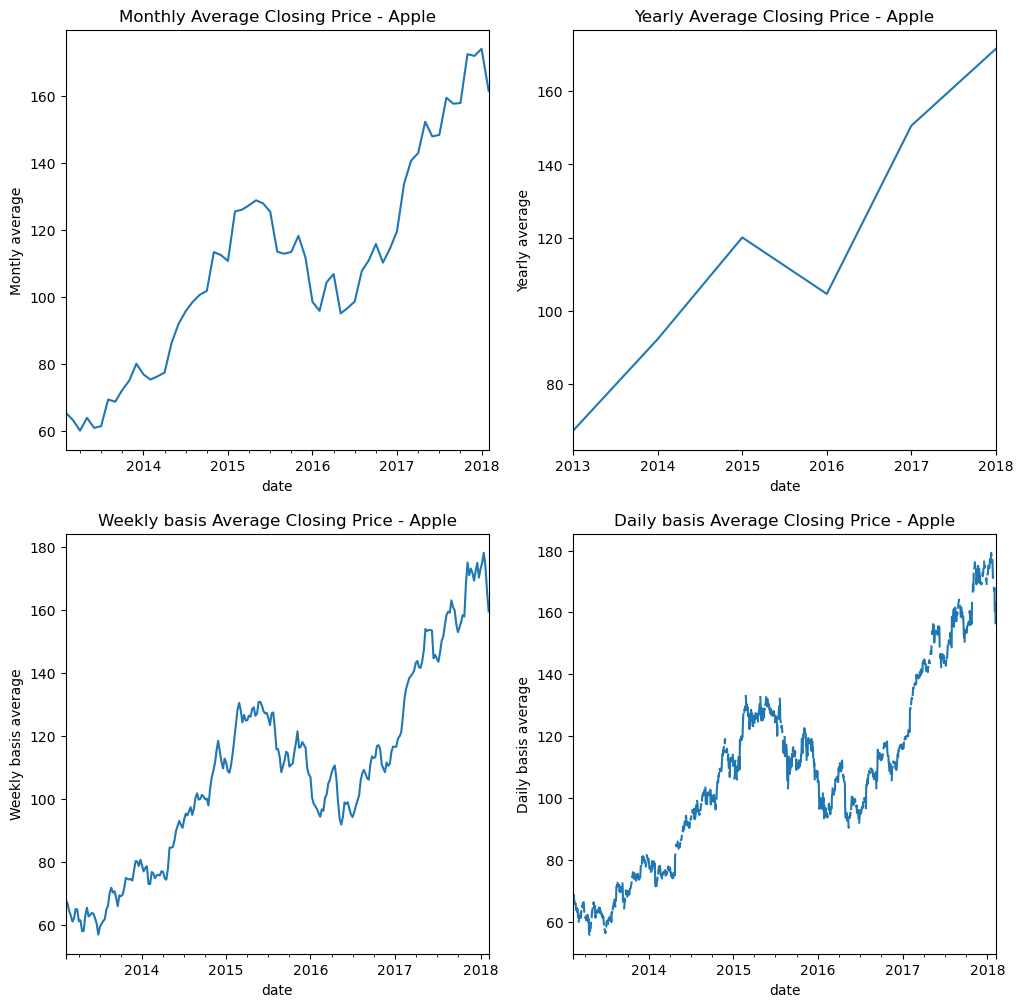

In [29]:
# Vizualizing the results

plt.figure(figsize=(12, 12))
plt.subplot(2,2,1)
apple['close'].resample('ME').mean().plot()
plt.ylabel('Montly average')
plt.title('Monthly Average Closing Price - Apple')

plt.subplot(2,2,2)
apple['close'].resample('YE').mean().plot()
plt.ylabel('Yearly average')
plt.title('Yearly Average Closing Price - Apple')

plt.subplot(2,2,3)
apple['close'].resample('W').mean().plot()
plt.ylabel('Weekly basis average')
plt.title('Weekly basis Average Closing Price - Apple')

plt.subplot(2,2,4)
apple['close'].resample('D').mean().plot()
plt.ylabel('Daily basis average')
plt.title('Daily basis Average Closing Price - Apple')

# Checking if the closing prices for these tech companies (Amazon, Apple, Google and Microsoft) are correlated or not

In [30]:
# Reshaping the data so that each company becomes a separate time series,
# with dates as the index and closing prices as values
prices = all_data.pivot_table(
    index='date',
    columns='Name',
    values='close'
)
prices.columns.name = None


# Correlations were computed after reshaping the data so that each company formed a separate, 
# date-aligned time series. This ensures that correlations are calculated between contemporaneous 
# observations rather than merely by row position.

In [31]:
prices.head()

,AAPL,AMZN,GOOG,MSFT
date,,,,
2013-02-08,67.8542,261.95,NaN,27.55
2013-02-11,68.5614,257.21,NaN,27.86
2013-02-12,66.8428,258.70,NaN,27.88
2013-02-13,66.7156,269.47,NaN,28.03
2013-02-14,66.6556,269.24,NaN,28.04


In [ ]:
corr = prices[['AAPL', 'AMZN', 'GOOG',	'MSFT']].corr()
corr

,AAPL,AMZN,GOOG,MSFT
AAPL,1.000000,0.819078,0.755274,0.899689
AMZN,0.819078,1.000000,0.978721,0.955977
GOOG,0.755274,0.978721,1.000000,0.967981
MSFT,0.899689,0.955977,0.967981,1.000000


 The highest correlation is beteween AMAZON and GOOGLE. <br>
 Followed by GOOGLE and MICROSOFT <br>
 And AMAZON and MICROSOFT


<Axes: >

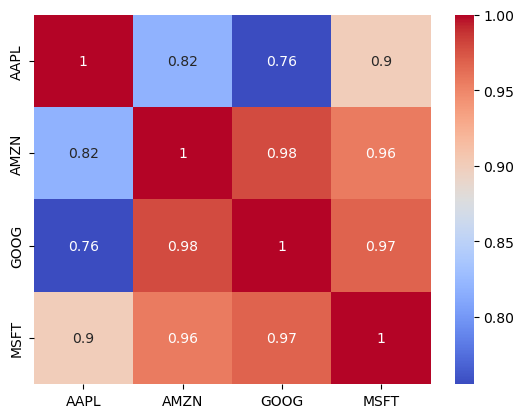

In [33]:
# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')


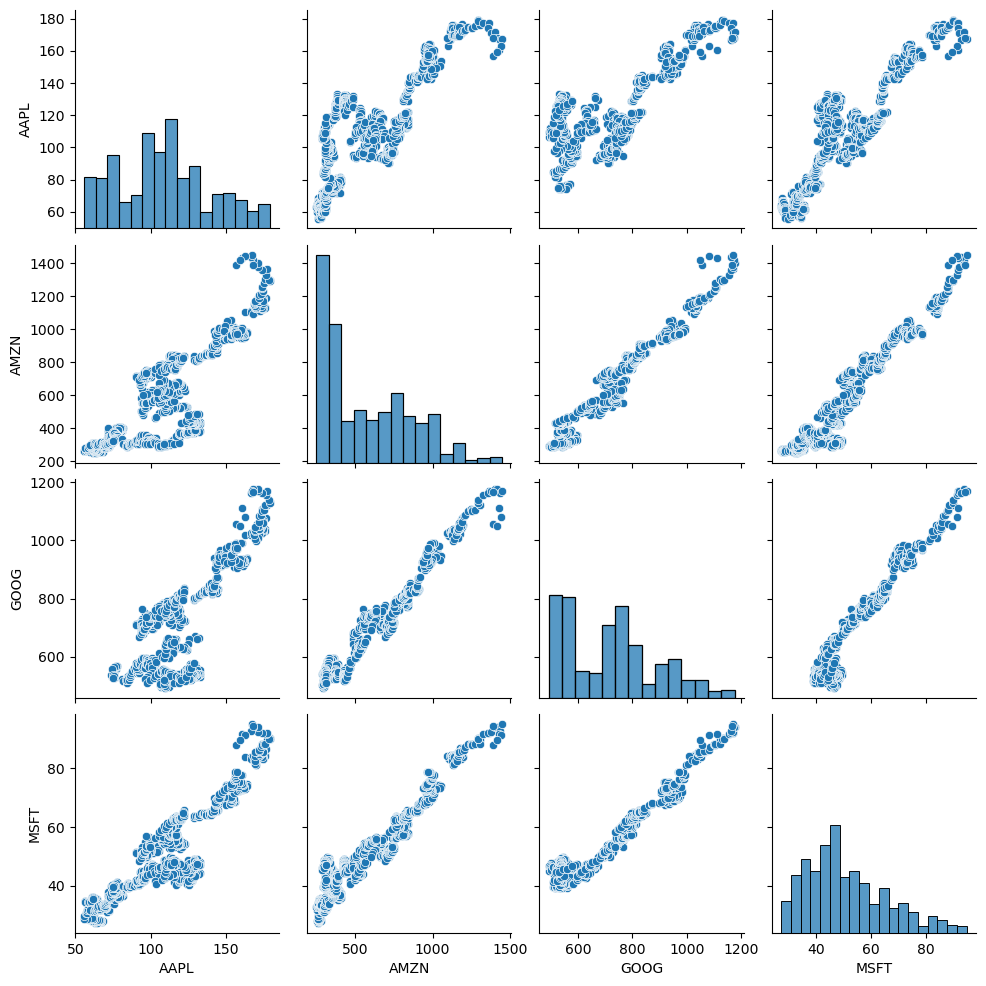

In [34]:
# We can also check the results using pair plot
col = ['AAPL', 'AMZN', 'GOOG',	'MSFT']
sns.pairplot(prices[col],kind='scatter', diag_kind='hist')

In this way, it is possible to see AMAZON and GOOGLE, MICROSOFT and GOOGLE, and AMAZON and MICROSOFT with a straight line, indicating a high correlation


# Analysing whether daily change in closing price of stocks or daily returns in stock are co-related or not

In [42]:
# Calculating the percentual changes
returns = prices.pct_change()*100
returns.columns = ['Apple_close_pct_change', 'Amazon_close_pct_change', 'Google_close_pct_change', 'Microsoft_close_pct_change']

In [43]:
returns

,Apple_close_pct_change,Amazon_close_pct_change,Google_close_pct_change,Microsoft_close_pct_change
date,,,,
2013-02-08,NaN,NaN,NaN,NaN
2013-02-11,1.042235,-1.809506,NaN,1.125227
2013-02-12,-2.506658,0.579293,NaN,0.071788
2013-02-13,-0.190297,4.163123,NaN,0.538020
2013-02-14,-0.089934,-0.085353,NaN,0.035676
...,...,...,...,...
2018-02-01,0.209043,-4.196734,-0.191463,-0.789391
2018-02-02,-4.339015,2.874101,-4.778625,-2.631021
2018-02-05,-2.498442,-2.793804,-5.045418,-4.118544


In [45]:
# Analysing if are there any correlations
returns.corr()

,Apple_close_pct_change,Amazon_close_pct_change,Google_close_pct_change,Microsoft_close_pct_change
Apple_close_pct_change,1.000000,0.287659,0.415487,0.366598
Amazon_close_pct_change,0.287659,1.000000,0.586230,0.402678
Google_close_pct_change,0.415487,0.586230,1.000000,0.579281
Microsoft_close_pct_change,0.366598,0.402678,0.579281,1.000000


<Axes: >

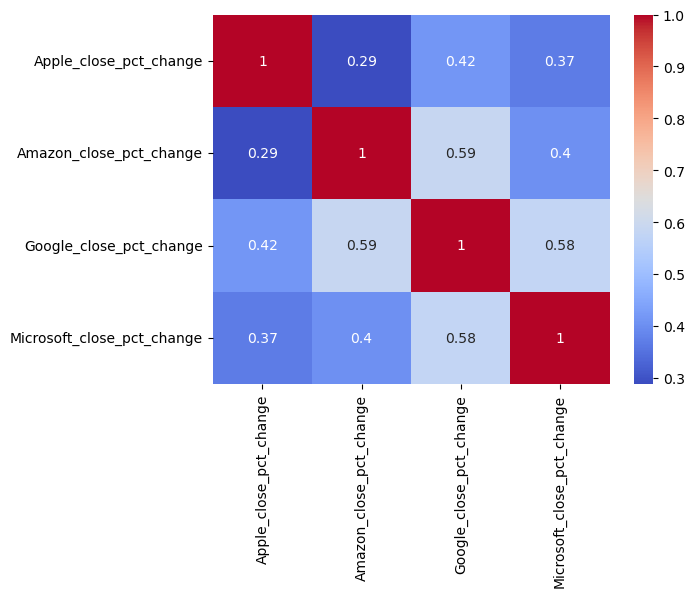

In [46]:
# Heatmap
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')

AMAZON and GOOGLE, followed by GOOGLE and MICROSOFT, are correlated to some extent, with correlation numbers of 0.59 and 0.58, respectively.